## Neural Network Model Evaluation

In [56]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Path
from pathlib import Path
from sklearn.model_selection import KFold
from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    KFold,
    ShuffleSplit, 
    StratifiedGroupKFold,
    StratifiedKFold,
    StratifiedShuffleSplit,
    TimeSeriesSplit
)

# loading epochs experiment results 
with open("results/epochs_experiment/epoch_results.json") as f:
    epoch_data = json.load(f)

train_accs = epoch_data["train_acc"]
test_accs = epoch_data["test_acc"]
val_accs = epoch_data["val_acc"]
train_losses = epoch_data["train_loss"]
val_losses = epoch_data["val_loss"]

# loading batch size experiment results 
with open("results/batch_experiment/batch_results.json") as f:
    batch_data = json.load(f)

# loading cross-validation folds
with open("results/folds_experiment/folds_results.json") as f:
    folds_data = json.load(f)

fold_accuracies = folds_data["fold_acc"]
mean_acc = folds_data["mean_acc"]
std_acc = folds_data["std_acc"]

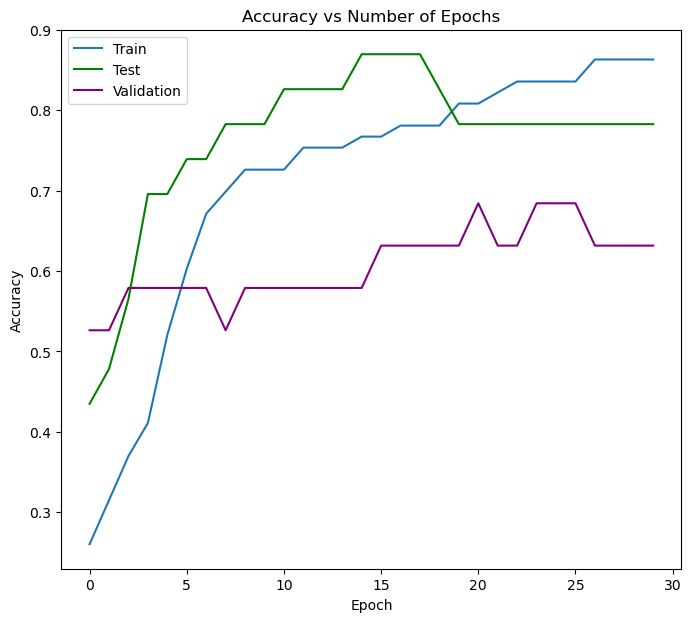

In [57]:
# --- epochs experimentation figure ---
plt.figure(figsize=(8, 7))
plt.plot(train_accs, label='Train')
plt.plot(test_accs, label='Test', color='green')
plt.plot(val_accs, label='Validation', color='purple')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Epochs")
plt.legend()
plt.show()

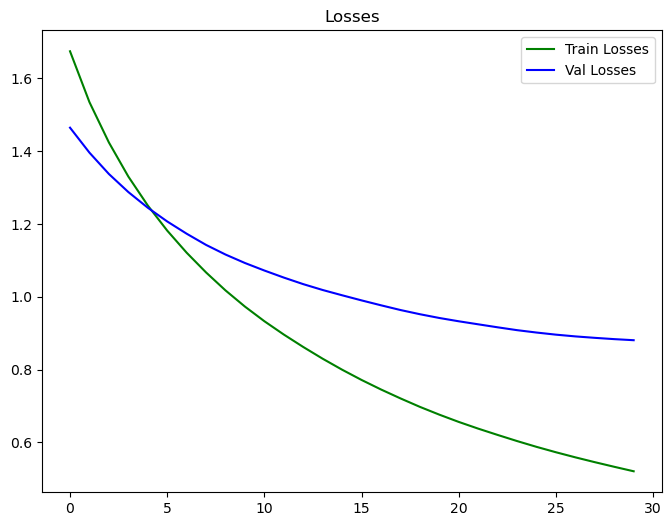

In [63]:
# --- loss vs accuracy curves ---
# accuracy
''' plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(train_accs, label="Train Accuracy", color="green")
plt.plot(val_accs, label="Val Accuracy", color="blue")
plt.title("Accuracy")
plt.legend() '''

# loss 
plt.figure(figsize=(8,6))
plt.plot(train_losses, label="Train Losses", color="green")
plt.plot(val_losses, label="Val Losses", color="blue")
plt.title("Losses")
plt.legend()

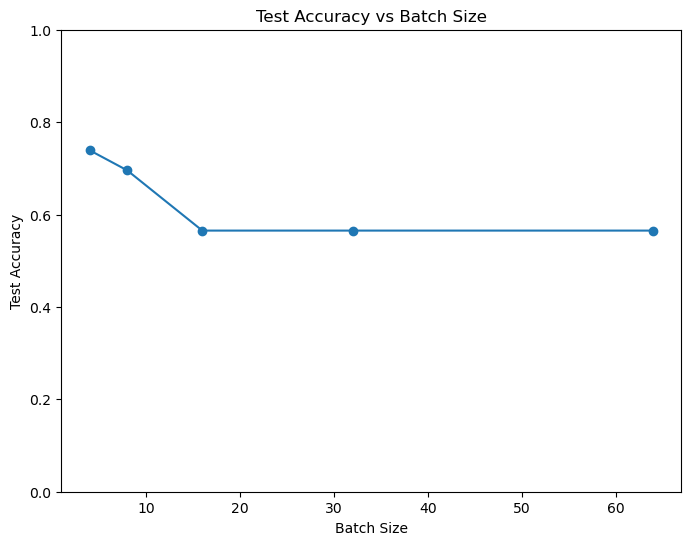

In [59]:
# --- batch size experimentation figure ---
batch_sizes = []
test_accuracies = []

for batch_size, data in batch_data.items(): 
    batch_sizes.append(int(batch_size))
    test_accuracies.append(data)

plt.figure(figsize=(8, 6))
plt.plot(batch_sizes, test_accuracies, marker="o")
plt.xlabel("Batch Size")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.title("Test Accuracy vs Batch Size")
# plt.xticks(batch_sizes)
plt.show()

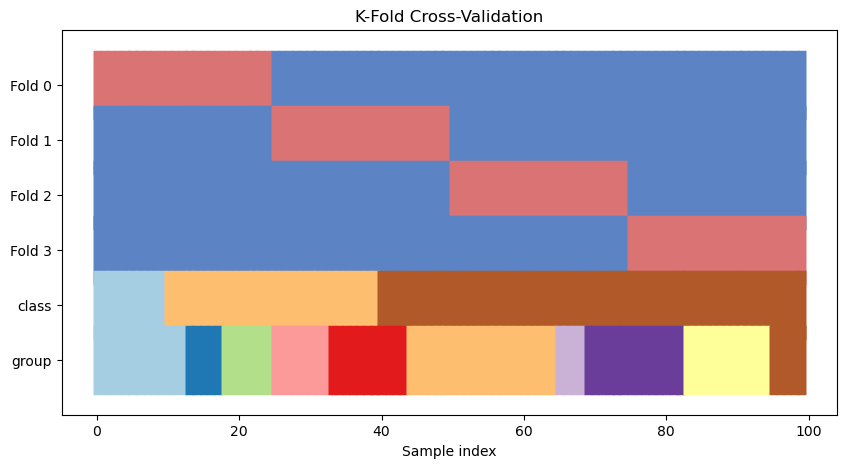

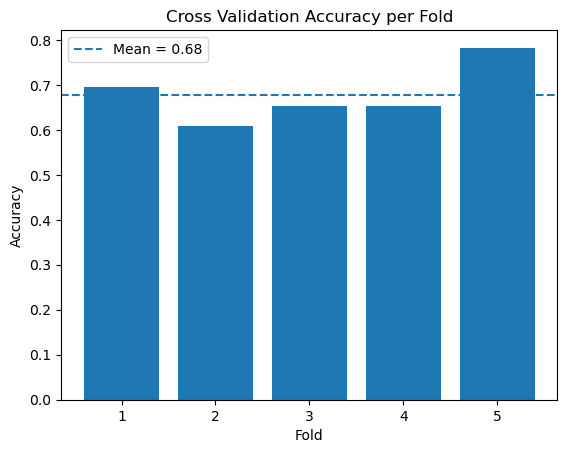

In [60]:
rng = np.random.RandomState(1338)
cmap_data = plt.cm.Paired
cmap_cv = plt.cm.coolwarm
n_splits = 4

n_points = 115
X = rng.randn(100, 10)
percentiles_classes = [0.1, 0.3, 0.6]
y = np.hstack([[ii] * int(100*perc) for ii, perc in enumerate(percentiles_classes)])

group_prior = rng.dirichlet([2] * 10)
groups = np.repeat(np.arange(10), rng.multinomial(100, group_prior))

def visualise_kfold_with_groups(classes, groups, n_splits=4):
    fig, ax = plt.subplots(figsize=(10, 5))

    kf = KFold(n_splits=n_splits, shuffle=False)

    for i, (train_idx, test_idx) in enumerate(kf.split(classes)):
        indices = np.arange(len(classes))

        train_colour = "#5C84C4"
        test_colour = "#DA7373"

        colors = np.array([train_colour] * len(classes))
        colors[test_idx] = test_colour

        ax.scatter(
            indices,
            [i] * len(classes),
            c=colors,
            marker="_",
            lw=50
        )

    ax.scatter(
        range(len(classes)),
        [n_splits] * len(classes),
        c=classes,
        marker="_",
        lw=50,
        cmap=cmap_data
    )

    ax.scatter(
        range(len(groups)),
        [n_splits + 1] * len(groups),
        c=groups,
        marker="_",
        lw=50,
        cmap=cmap_data
    )

    ax.set(
        ylim=[-1, n_splits + 2],
        yticks=list(range(n_splits)) + [n_splits, n_splits + 1],
        yticklabels=[f"Fold {i}" for i in range(n_splits)] + ["class", "group"],
        xlabel="Sample index",
        title="K-Fold Cross-Validation"
    )

    ax.invert_yaxis()

    plt.show()

visualise_kfold_with_groups(y, groups, n_splits=4)

# --- results fromn cross-validation ---
folds = np.arange(1, len(fold_accuracies) + 1)

plt.figure()
plt.bar(folds, fold_accuracies)

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Cross Validation Accuracy per Fold")

mean_acc = np.mean(fold_accuracies)
plt.axhline(mean_acc, linestyle='--', label=f"Mean = {mean_acc:.2f}")
plt.legend()
plt.show()